In [2]:
"""图像分类CNN"""
import torch
import torch.nn as nn
from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor  # pip install torchvision -i https://mirrors.aliyun.com/pypi/simple/
import matplotlib.pyplot as plt
from torchsummary import summary
import time
from torch.utils.data import DataLoader
import torch.optim as optim

# todo1 加载数据集:训练集数据和测试数据
def create_dataset():
    train = CIFAR10(root="./data", train=True, transform=ToTensor(), download=True)
    valid = CIFAR10(root="./data", train=False, transform=ToTensor(), download=True)
    # 返回数据集结果
    return train, valid

Files already downloaded and verified
Files already downloaded and verified
训练集数据集: (50000, 32, 32, 3) type: <class 'numpy.ndarray'>
测试集数据集: (10000, 32, 32, 3) type: <class 'numpy.ndarray'>
数据集类别: {'airplane': 0, 'automobile': 1, 'bird': 2, 'cat': 3, 'deer': 4, 'dog': 5, 'frog': 6, 'horse': 7, 'ship': 8, 'truck': 9}


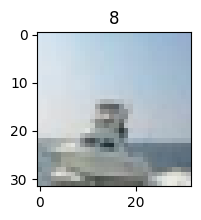

验证集准确率：0.6057


In [4]:
BATCH_SIZE = 8 # 批处理大小

# todo2 搭建图像分类网络模型
class ImageModel(nn.Module):
    def __init__(self):
        super().__init__()
        # 搭建神经网络
        # 第一个卷积层:输入图像通道数3，输出6个特征图，卷积核尺寸3*3
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=6, kernel_size =3)
        # 第一个池化层：宽高: 2*2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # 第二个卷积层:输入图像通道数6，输出16个特征图，卷积核尺寸3*3
        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size =3)
        # 第二个池化层：宽高: 2*2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # 第一个全连接层:输入维度为16*6*6 = 576，输出维度为120
        self.linear1 = nn.Linear(16 * 6 * 6, 120)
        # 第二个全连接层:输入维度为120，输出维度为84
        self.linear2 = nn.Linear(120, 84)
        # 输出层:输入维度为120，输出分类为10（0-9）
        self.out = nn.Linear(84, 10)

    # 前向传播
    def forward(self, x):
        # 第一个卷积 + relu + 池化
        x= torch.relu(self.conv1(x))
        x = self.pool1(x)

        # 第二个卷积 + relu + 池化
        x= torch.relu(self.conv2(x))
        x = self.pool2(x)

        # 将特征图转换为向量的形式
        # x.shape = (batch_size, 16, 6, 6) 转换为 （batch_size, 576）
        # x = torch.flatten(x, 1)
        x = x.reshape(x.shape[0], -1)

        # 全连接层
        x = torch.relu(self.linear1(x))
        x = torch.relu(self.linear2(x))
        x = self.out(x)
        # 输出结果
        return x

# todo3 训练模型
def train(train_dataset):
    model = ImageModel()

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    model.train()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    epochs = 10
    for epoch in range(epochs):
        total_loss = 0 # 总损失
        sum = 0 # 样本数量
        correct = 0
        start_time = time.time()
        for x, y in train_loader:
            output = model(x)
            loss = criterion(output, y)
            optimizer.zero_grad()
            loss.backward()  # 反向传播
            optimizer.step()
            # loss为8次的平均损失，乘以len(y)表示8个样本的总损失值
            total_loss += loss.item() * len(y)
            y_pred = torch.argmax(output, -1)
            correct += (y_pred == y).sum() # 8个样本中预测正确的个数
            sum += len(y)
        print(f"第{epoch+1}轮：损失值：{total_loss / sum:.4f}，准确率：{correct/sum:.4f}，训练时间：{time.time()-start_time:.2f}秒")
    torch.save(model.state_dict(), "./model/image_classify_model.pth")

# 模型验证
def evaluate(valid_dataset):
    model = ImageModel()
    model.load_state_dict(torch.load("./model/image_classify_model.pth"))
    valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False)
    model.eval()
    correct = 0
    sum = 0
    for x, y in valid_loader:
        # print(x.shape) # (8, 3, 32, 32)
        # print(y.shape) # (8,)
        output = model(x)
        # print(output.shape) #(8, 10)
        y_pred = torch.argmax(output, -1)
        # print(y_pred.shape) #(8,)
        correct += (y_pred == y).sum()  # 8个样本中预测正确的个数
        sum += len(y)
    print(f"验证集准确率：{correct/sum:.4f}")

if __name__ == '__main__':
    # 数据集加载
    train_dataset, valid_dataset = create_dataset()
    print("训练集数据集:", train_dataset.data.shape, "type:", type(train_dataset.data))  # (50000, 32, 32, 3) 5万张3通道32*32的图片
    print("测试集数据集:", valid_dataset.data.shape, "type:", type(valid_dataset.data))  # (10000, 32, 32, 3)
    print("数据集类别:", train_dataset.class_to_idx)

    # 图像展示
    plt.figure(figsize=(2, 2))
    plt.imshow(train_dataset.data[100])
    plt.title(train_dataset.targets[100])
    plt.show()

    # 模型展示
    model = ImageModel()
    # model.forward(torch.randn(2, 3, 32, 32))
    # summary(model, input_size=(3, 32, 32), batch_size=8)
    # 模型训练
    # train(train_dataset)

    # 模型预测
    evaluate(valid_dataset)